In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# **HateXplain dataset**

Link to the dataset: https://www.kaggle.com/datasets/sayankr007/cyber-bullying-data-for-multi-label-classification

I have the Processed and Labelled version of The Dataset Converted from CSV version of the Original hateXplain Dataset

In [2]:
df = pd.read_csv('final_hateXplain.csv')
df['Miscellaneous'] = df['Miscellaneous'].fillna('None')

In [3]:
#Defining "Double Marginalization" (Intersectionality)
#Target is a Woman AND belongs to another minority group
def is_minority(row):
    # Checks if any identity marker other than gender is present
    has_race = row['Race'] != 'No_race'
    has_religion = row['Religion'] != 'Nonreligious'
    has_orientation = row['Sexual Orientation'] != 'No_orientation'
    has_misc = row['Miscellaneous'] not in ['None', 'Other']
    return any([has_race, has_religion, has_orientation, has_misc])

df['is_minority'] = df.apply(is_minority, axis=1)
df['intersectional_women'] = (df['Gender'] == 'Women') & (df['is_minority'] == True)

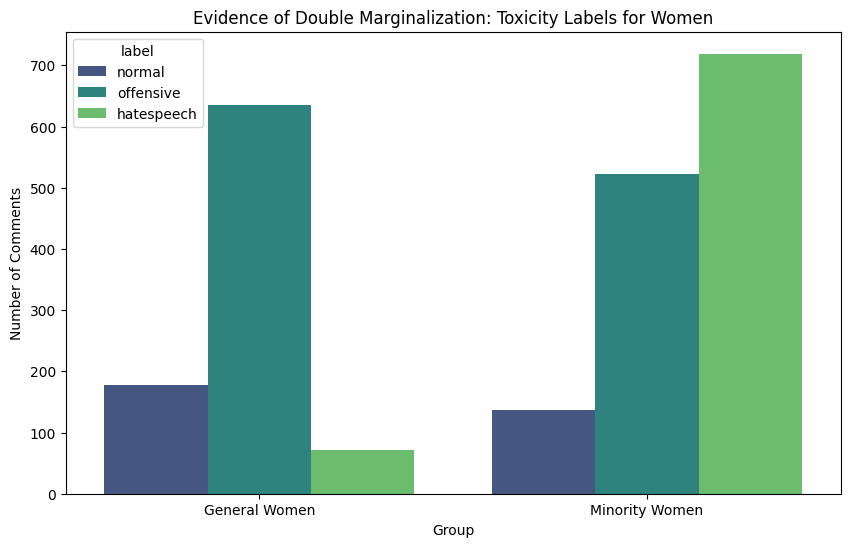

In [4]:
# Visualization: Toxicity Distribution
# Comparing General Women vs. Intersectional (Minority) Women
women_df = df[df['Gender'] == 'Women'].copy()
women_df['Group'] = women_df['is_minority'].map({True: 'Minority Women', False: 'General Women'})

plt.figure(figsize=(10, 6))
sns.countplot(data=women_df, x='Group', hue='label', palette='viridis')
plt.title('Evidence of Double Marginalization: Toxicity Labels for Women')
plt.ylabel('Number of Comments')
plt.show()

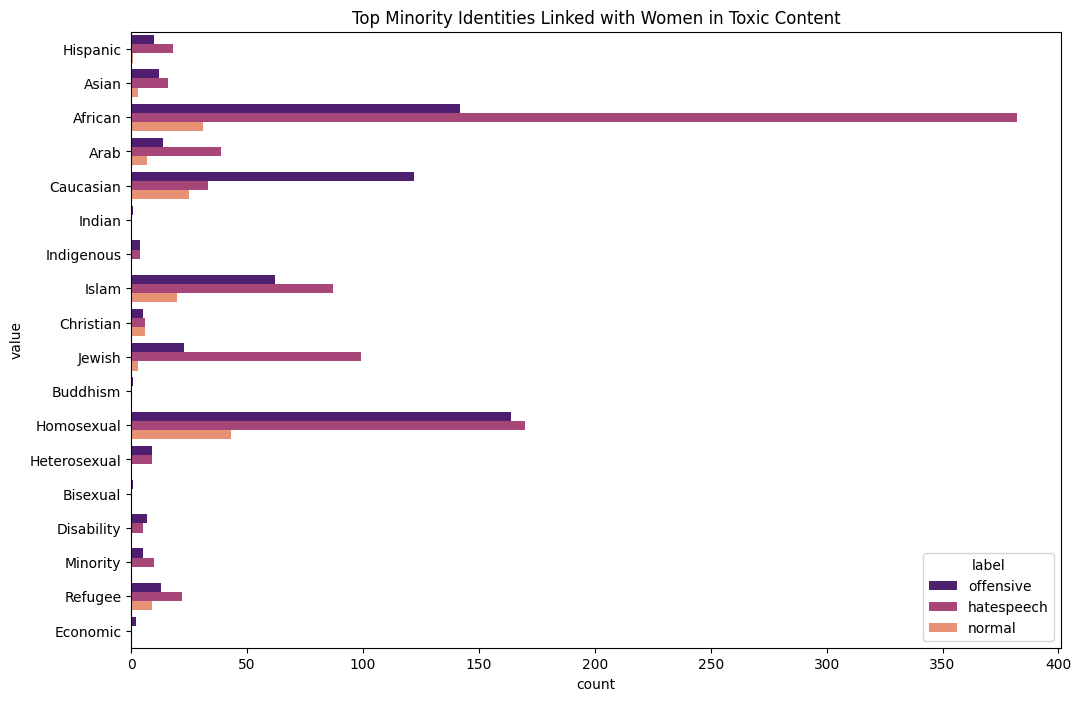

In [5]:
# Visualization: Top Intersectional Identities
# Breakdown of which minority identities are most targeted when the victim is a woman
intersectional_women_df = df[df['intersectional_women']]
melted = pd.melt(intersectional_women_df, id_vars=['label'],
                 value_vars=['Race', 'Religion', 'Sexual Orientation', 'Miscellaneous'])
melted = melted[~melted['value'].isin(['No_race', 'Nonreligious', 'No_orientation', 'None', 'Other'])]

plt.figure(figsize=(12, 8))
sns.countplot(data=melted, y='value', hue='label', palette='magma')
plt.title('Top Minority Identities Linked with Women in Toxic Content')
plt.show()

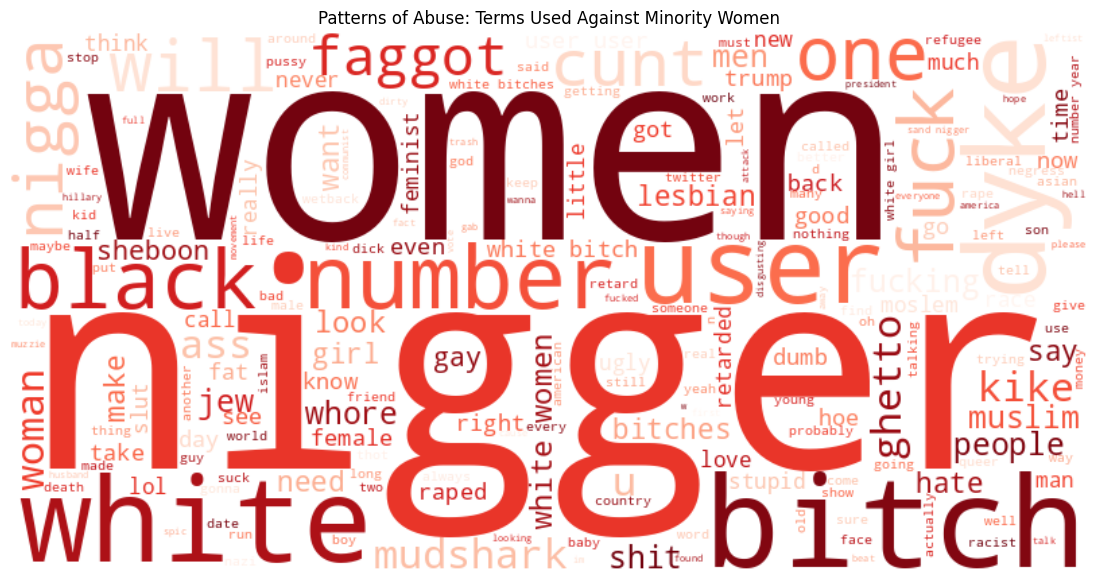

In [6]:
# 5. POC: Word Cloud for Toxic Content targeting Minority Women
toxic_text = " ".join(comment for comment in intersectional_women_df[intersectional_women_df['label'] != 'normal']['comment'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(toxic_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Patterns of Abuse: Terms Used Against Minority Women')
plt.show()

# **Measuring-hate-speech dataset**

*Dataset* link: https://huggingface.co/datasets/ucberkeley-dlab/measuring-hate-speech

In [11]:
df1 = pd.read_parquet("hf://datasets/ucberkeley-dlab/measuring-hate-speech/data/train-00000-of-00001.parquet")
df.shape

(135556, 143)

In [13]:
# Handle Nulls
# In the Berkeley dataset, identity flags are often 0.0, 1.0, or NaN.
target_cols = [c for c in df1.columns if c.startswith('target_')]
df1[target_cols] = df1[target_cols].fillna(0).astype(int)

# Text Cleaning
# Clean the text column specifically
df1['text'] = df1['text'].astype(str).str.replace(r'&amp;', '&', regex=True)
df1['text'] = df1['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# The Mean-Max Aggregation
# We group by 'comment_id' to collapse the multiple annotators.
agg_strategy = {col: 'max' for col in target_cols} # Max: If ANYONE flagged the identity
agg_strategy['hate_speech_score'] = 'mean'        # Mean: The average social consensus
agg_strategy['text'] = 'first'                    # Text: Keep the cleaned version

df_clean = df1.groupby('comment_id').agg(agg_strategy).reset_index()

# Define Double Marginalization Labels
# We look for the intersection of Gender + other minority pillars
minority_flags = ['target_race', 'target_religion', 'target_sexuality', 'target_disability']
df_clean['is_intersectional_woman'] = (df_clean['target_gender'] == 1) & (df_clean[minority_flags].any(axis=1))

print(f"Dataset successfully cleaned. Unique comments for analysis: {len(df_clean)}")

Dataset successfully cleaned. Unique comments for analysis: 39565


In [14]:
df_clean.shape

(39565, 69)

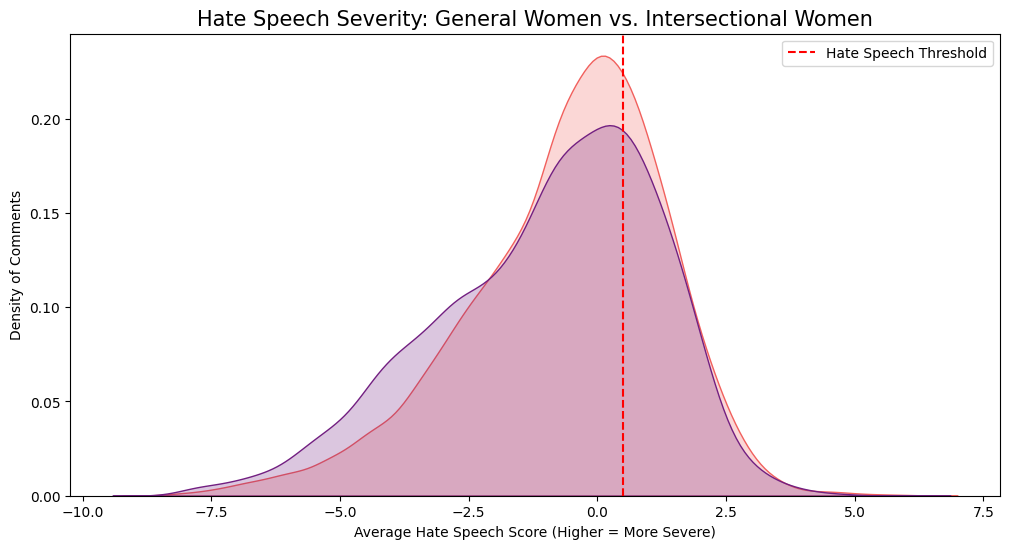

In [15]:
# Visualization A: Severity Density Plot
plt.figure(figsize=(12, 6))
women_subset = df_clean[df_clean['target_gender'] == 1].copy()
women_subset['Category'] = women_subset['is_intersectional_woman'].map({
    True: 'Minority/Intersectional Women',
    False: 'General Women'
})

sns.kdeplot(data=women_subset, x='hate_speech_score', hue='Category', fill=True, palette='magma', common_norm=False)
plt.axvline(x=0.5, color='red', linestyle='--', label='Hate Speech Threshold')
plt.title('Hate Speech Severity: General Women vs. Intersectional Women', fontsize=15)
plt.xlabel('Average Hate Speech Score (Higher = More Severe)')
plt.ylabel('Density of Comments')
plt.legend()
plt.show()

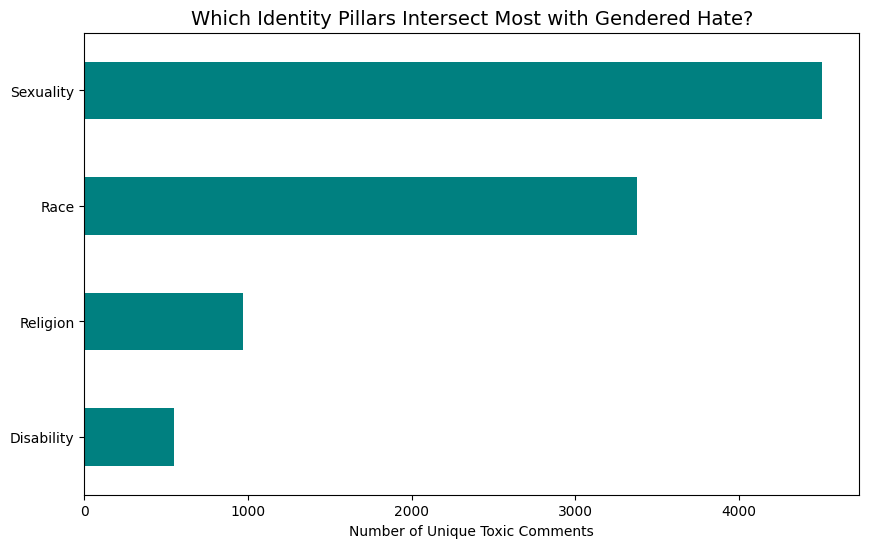

In [16]:
# Visualization B: Intersectional Pillar Breakdown
plt.figure(figsize=(10, 6))
pillar_counts = df_clean[df_clean['is_intersectional_woman']][minority_flags].sum()
pillar_counts.index = ['Race', 'Religion', 'Sexuality', 'Disability']
pillar_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Which Identity Pillars Intersect Most with Gendered Hate?', fontsize=14)
plt.xlabel('Number of Unique Toxic Comments')
plt.show()

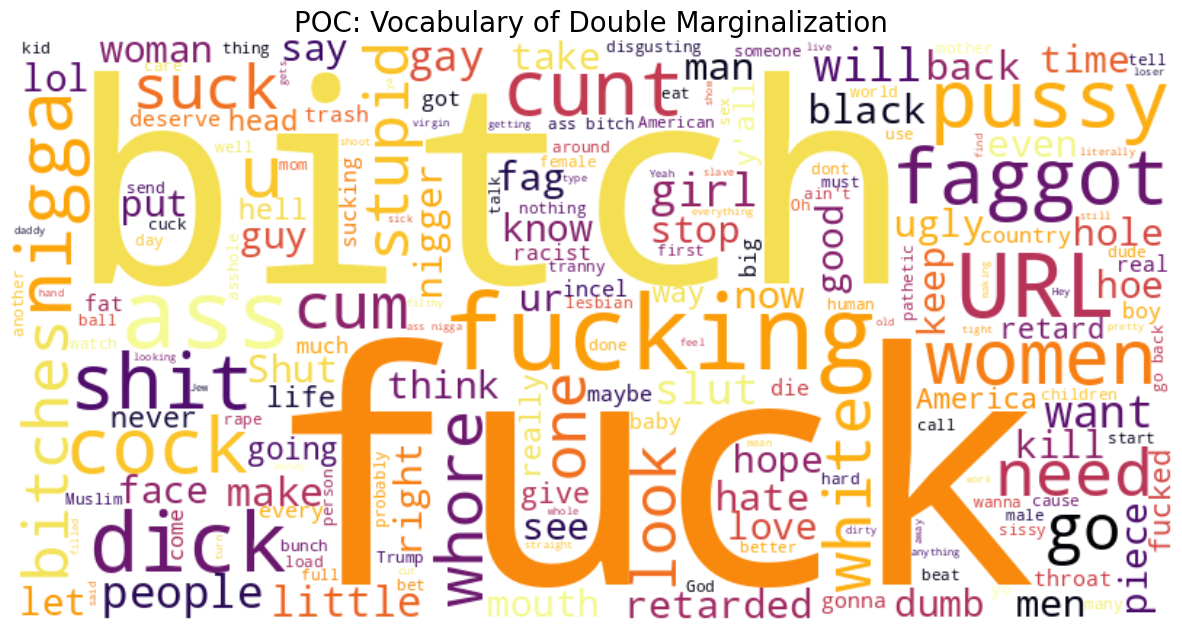

In [17]:
# Visualization C: Word Cloud PoC
# Filter for intersectional women with scores above the threshold
toxic_text = " ".join(df_clean[(df_clean['is_intersectional_woman']) & (df_clean['hate_speech_score'] > 0.5)]['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(toxic_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('POC: Vocabulary of Double Marginalization', fontsize=20)
plt.show()